# Original TeleSABRE vs BLaRTSABRE

In [28]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
})

C_BLART = "#2563eb"
C_TELE  = "#e11d48"

In [29]:
BLART_PATH = "blartsabre_improved.json"
TELE_PATH  = "og_telesabre_opt_true.json"

with open(BLART_PATH) as f:
    blart_raw = json.load(f)
with open(TELE_PATH) as f:
    tele_raw = json.load(f)

# Handle both list-of-dicts and dict-of-dicts
if isinstance(blart_raw, dict):
    blart_raw = list(blart_raw.values())
if isinstance(tele_raw, dict):
    tele_raw = list(tele_raw.values())

# Match circuits by name
blart_by_name = {r["name"]: r for r in blart_raw}
tele_by_name  = {r["name"]: r for r in tele_raw}
names = sorted(set(blart_by_name) & set(tele_by_name))

blart = [blart_by_name[n] for n in names]
tele  = [tele_by_name[n] for n in names]

print(f"{len(names)} circuits")
for n in names:
    print(f"  {n}")

10 circuits
  ae_nativegates_ibm_qiskit_opt3_25
  ae_nativegates_ibm_qiskit_opt3_64
  ghz_nativegates_ibm_qiskit_opt3_25
  ghz_nativegates_ibm_qiskit_opt3_64
  graphstate_nativegates_ibm_qiskit_opt3_25
  graphstate_nativegates_ibm_qiskit_opt3_64
  qft_nativegates_ibm_qiskit_opt3_25
  qft_nativegates_ibm_qiskit_opt3_64
  random_nativegates_ibm_qiskit_opt3_25
  random_nativegates_ibm_qiskit_opt3_64


In [30]:
# Original circuit properties
og_cx = np.array([b["og_cx"] for b in blart])
og_depth = np.array([b["og_depth"] for b in blart])
og_size = np.array([b["og_size"] for b in blart])
num_qubits = np.array([b["num_qubits"] for b in blart])

# BLART SABRE
b_local_swaps = np.array([b["local_swaps"] for b in blart])
b_remote_swaps = np.array([b["remote_swaps"] for b in blart])
b_telegates = np.array([b["telegates"] for b in blart])
b_time = np.array([b["mapping_time"] / b["iterations"] for b in blart])

# TeleSABRE
t_swaps     = np.array([t["swaps"] for t in tele])
t_teleports = np.array([t["teleports"] for t in tele])
t_telegates = np.array([t["telegates"] for t in tele])
t_time      = np.array([t["mapping_time"] / t["iterations"] for t in tele])
t_fail   = np.array([t["solving_deadlock"] for t in tele])

# Derived: inter-core ops
b_remote_ops = b_remote_swaps + b_telegates
t_remote_ops = t_teleports + t_telegates

In [35]:
def short_name(name, max_len=20):
    name = name.replace("_nativegates_ibm_qiskit_opt3", "")
    name = name.replace("_nativegates_ibm_qiskit", "")
    return name[:max_len]

def yn(x):
    return "Y" if x else "N"

# Derived metrics
b_total_swaps = b_local_swaps + b_remote_swaps
t_total_moves = t_swaps + t_teleports

# Column widths
W_NAME = 20
W_FAIL = 6
W_QB   = 3
W_B1   = 7
W_T1   = 7
W_D1   = 7
W_CMP  = 3
W_BTG  = 6
W_TTG  = 6
W_DTG  = 7
W_BREM = 8
W_TREM = 8
W_DREM = 7
W_BT   = 7
W_TT   = 7
W_DT   = 8

header = (
    f"{'Circuit':<{W_NAME}} {'T_fail':>{W_FAIL}} {'Qb':>{W_QB}} | "
    f"{'B_L+R':>{W_B1}} {'T_S+T':>{W_T1}} {'Δ':>{W_D1}} {'B<T':>{W_CMP}} | "
    f"{'B_TG':>{W_BTG}} {'T_TG':>{W_TTG}} {'Δ':>{W_DTG}} {'B<T':>{W_CMP}} | "
    f"{'B_RemOp':>{W_BREM}} {'T_RemOp':>{W_TREM}} {'Δ':>{W_DREM}} {'B<T':>{W_CMP}} | "
    f"{'B_t(s)':>{W_BT}} {'T_t(s)':>{W_TT}} {'Δ':>{W_DT}} {'B<T':>{W_CMP}}"
)

print(header)
print("=" * len(header))

# summary counters
moves_better = 0
tg_better = 0
rem_better = 0
time_better = 0

d_moves_list = []
d_tg_list = []
d_rem_list = []
d_time_list = []

for i, name in enumerate(names):
    failed = bool(t_fail[i])

    if failed:
        t_moves_disp = "FAIL"
        t_tg_disp    = "FAIL"
        t_rem_disp   = "FAIL"
        t_time_disp  = "FAIL"

        d_moves_disp = "FAIL"
        d_tg_disp    = "FAIL"
        d_rem_disp   = "FAIL"
        d_time_disp  = "FAIL"

        moves_win = True
        tg_win    = True
        rem_win   = True
        time_win  = True
    else:
        d_moves = b_total_swaps[i] - t_total_moves[i]
        d_tg    = b_telegates[i] - t_telegates[i]
        d_rem   = b_remote_ops[i] - t_remote_ops[i]
        d_time  = b_time[i] - t_time[i]

        t_moves_disp = f"{t_total_moves[i]:>{W_T1}.0f}"
        t_tg_disp    = f"{t_telegates[i]:>{W_TTG}.0f}"
        t_rem_disp   = f"{t_remote_ops[i]:>{W_TREM}.0f}"
        t_time_disp  = f"{t_time[i]:>{W_TT}.1f}"

        d_moves_disp = f"{d_moves:+{W_D1}.0f}"
        d_tg_disp    = f"{d_tg:+{W_DTG}.0f}"
        d_rem_disp   = f"{d_rem:+{W_DREM}.0f}"
        d_time_disp  = f"{d_time:+{W_DT}.1f}"

        d_moves_list.append(d_moves)
        d_tg_list.append(d_tg)
        d_rem_list.append(d_rem)
        d_time_list.append(d_time)

        moves_win = d_moves < 0
        tg_win    = d_tg < 0
        rem_win   = d_rem < 0
        time_win  = d_time < 0

    moves_better += int(moves_win)
    tg_better    += int(tg_win)
    rem_better   += int(rem_win)
    time_better  += int(time_win)

    print(
        f"{short_name(name):<{W_NAME}} {yn(failed):>{W_FAIL}} {num_qubits[i]:>{W_QB}} | "
        f"{b_total_swaps[i]:>{W_B1}.0f} {t_moves_disp:>{W_T1}} {d_moves_disp:>{W_D1}} {yn(moves_win):>{W_CMP}} | "
        f"{b_telegates[i]:>{W_BTG}.0f} {t_tg_disp:>{W_TTG}} {d_tg_disp:>{W_DTG}} {yn(tg_win):>{W_CMP}} | "
        f"{b_remote_ops[i]:>{W_BREM}.0f} {t_rem_disp:>{W_TREM}} {d_rem_disp:>{W_DREM}} {yn(rem_win):>{W_CMP}} | "
        f"{b_time[i]:>{W_BT}.1f} {t_time_disp:>{W_TT}} {d_time_disp:>{W_DT}} {yn(time_win):>{W_CMP}}"
    )

print("=" * len(header))

n = len(names)
tele_fail_count = int(np.sum(t_fail))

print(
    f"{'BETTER COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{moves_better}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {f'{tg_better}/{n}':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {f'{rem_better}/{n}':>{W_DREM}} {'':>{W_CMP}} | "
    f"{'':>{W_BT}} {'':>{W_TT}} {f'{time_better}/{n}':>{W_DT}} {'':>{W_CMP}}"
)

print(
    f"{'T_FAIL COUNT':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
    f"{'':>{W_B1}} {'':>{W_T1}} {f'{tele_fail_count}/{n}':>{W_D1}} {'':>{W_CMP}} | "
    f"{'':>{W_BTG}} {'':>{W_TTG}} {'':>{W_DTG}} {'':>{W_CMP}} | "
    f"{'':>{W_BREM}} {'':>{W_TREM}} {'':>{W_DREM}} {'':>{W_CMP}} | "
    f"{'':>{W_BT}} {'':>{W_TT}} {'':>{W_DT}} {'':>{W_CMP}}"
)

if d_moves_list:
    d_moves_arr = np.array(d_moves_list, dtype=float)
    d_tg_arr    = np.array(d_tg_list, dtype=float)
    d_rem_arr   = np.array(d_rem_list, dtype=float)
    d_time_arr  = np.array(d_time_list, dtype=float)

    print(
        f"{'MEAN Δ (B-T)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.mean(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.mean(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.mean(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BT}} {'':>{W_TT}} {np.mean(d_time_arr):>{W_DT}.1f} {'':>{W_CMP}}"
    )

    print(
        f"{'MEDIAN Δ (B-T)':<{W_NAME}} {'':>{W_FAIL}} {'':>{W_QB}} | "
        f"{'':>{W_B1}} {'':>{W_T1}} {np.median(d_moves_arr):>{W_D1}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BTG}} {'':>{W_TTG}} {np.median(d_tg_arr):>{W_DTG}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BREM}} {'':>{W_TREM}} {np.median(d_rem_arr):>{W_DREM}.1f} {'':>{W_CMP}} | "
        f"{'':>{W_BT}} {'':>{W_TT}} {np.median(d_time_arr):>{W_DT}.1f} {'':>{W_CMP}}"
    )

Circuit              T_fail  Qb |   B_L+R   T_S+T       Δ B<T |   B_TG   T_TG       Δ B<T |  B_RemOp  T_RemOp       Δ B<T |  B_t(s)  T_t(s)        Δ B<T
ae_25                     N  25 |     247     414    -167   Y |     82     14     +68   N |      192       88    +104   N |    39.8    55.5    -15.6   Y
ae_64                     N  64 |    1050    2549   -1499   Y |    230     80    +150   N |      615      391    +224   N |   561.4   781.0   -219.6   Y
ghz_25                    N  25 |      22       9     +13   N |      3      0      +3   N |       13        2     +11   N |     0.1     0.7     -0.6   Y
ghz_64                    N  64 |      82      38     +44   N |      5      0      +5   N |       40        6     +34   N |     0.6     2.5     -1.9   Y
graphstate_25             N  25 |      16      18      -2   Y |      2      1      +1   N |        9        4      +5   N |     0.5     3.5     -3.1   Y
graphstate_64             N  64 |      71     147     -76   Y |      4      2     

> B_L+R = BLaRTSABRE local swaps + remote swaps

> T_S+T = TeleSABRE local swaps + teleports

> B_TG = BLaRTSABRE telegates

> T_TG = TeleSABRE telegates

> B_RemOp = BLaRTSABRE remote swaps + telegates

> B_RemOp = TeleSABRE teleports + telegates

> B_t(s) = BLaRTSABRE run time

> T_t(s) = TeleSABRE run time

In [33]:
def bar_compare(blart_vals, tele_vals, ylabel, title, blart_label="BLART SABRE", tele_label="TeleSABRE"):
    x = np.arange(len(names))
    w = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - w/2, blart_vals, w, label=blart_label, color=C_BLART, edgecolor="white")
    ax.bar(x + w/2, tele_vals, w, label=tele_label, color=C_TELE, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([short_name(n) for n in names], rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

In [34]:
bar_compare(b_swaps, t_swaps + t_teleports,
            "Count", "Total SWAPs  vs  SWAPs + Teleports",
            blart_label="BLART SWAPs", tele_label="TeleSABRE SWAPs+Teleports")

NameError: name 'b_swaps' is not defined

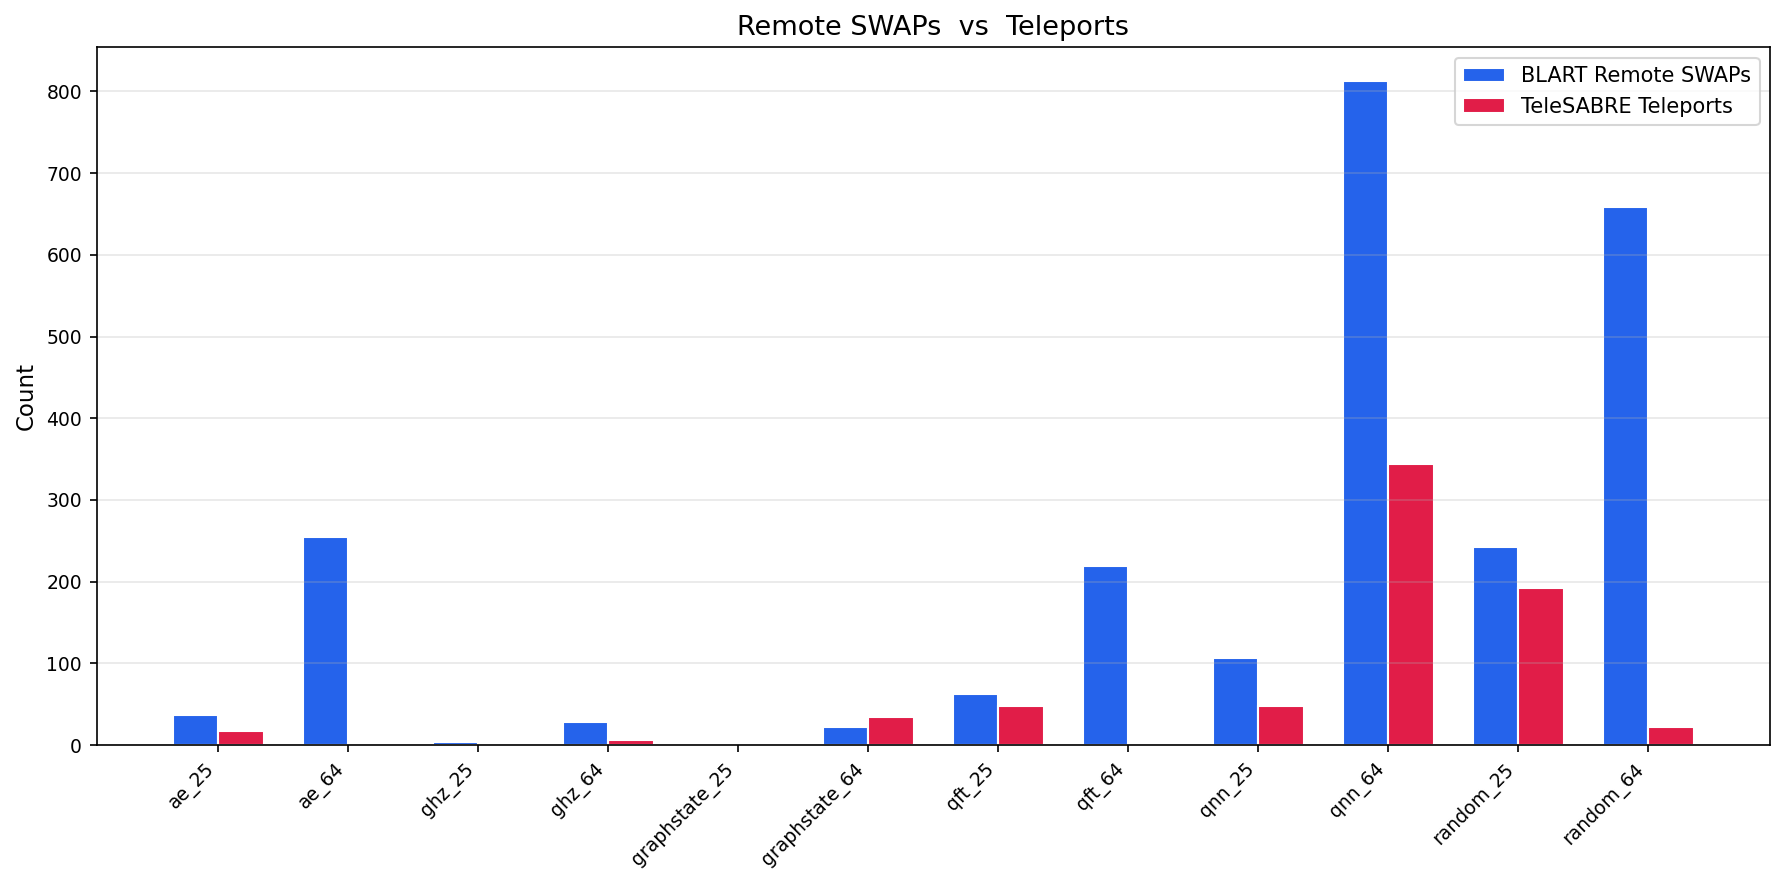

In [ ]:
bar_compare(b_swaps_remote, t_teleports,
            "Count", "Remote SWAPs  vs  Teleports",
            blart_label="BLART Remote SWAPs", tele_label="TeleSABRE Teleports")

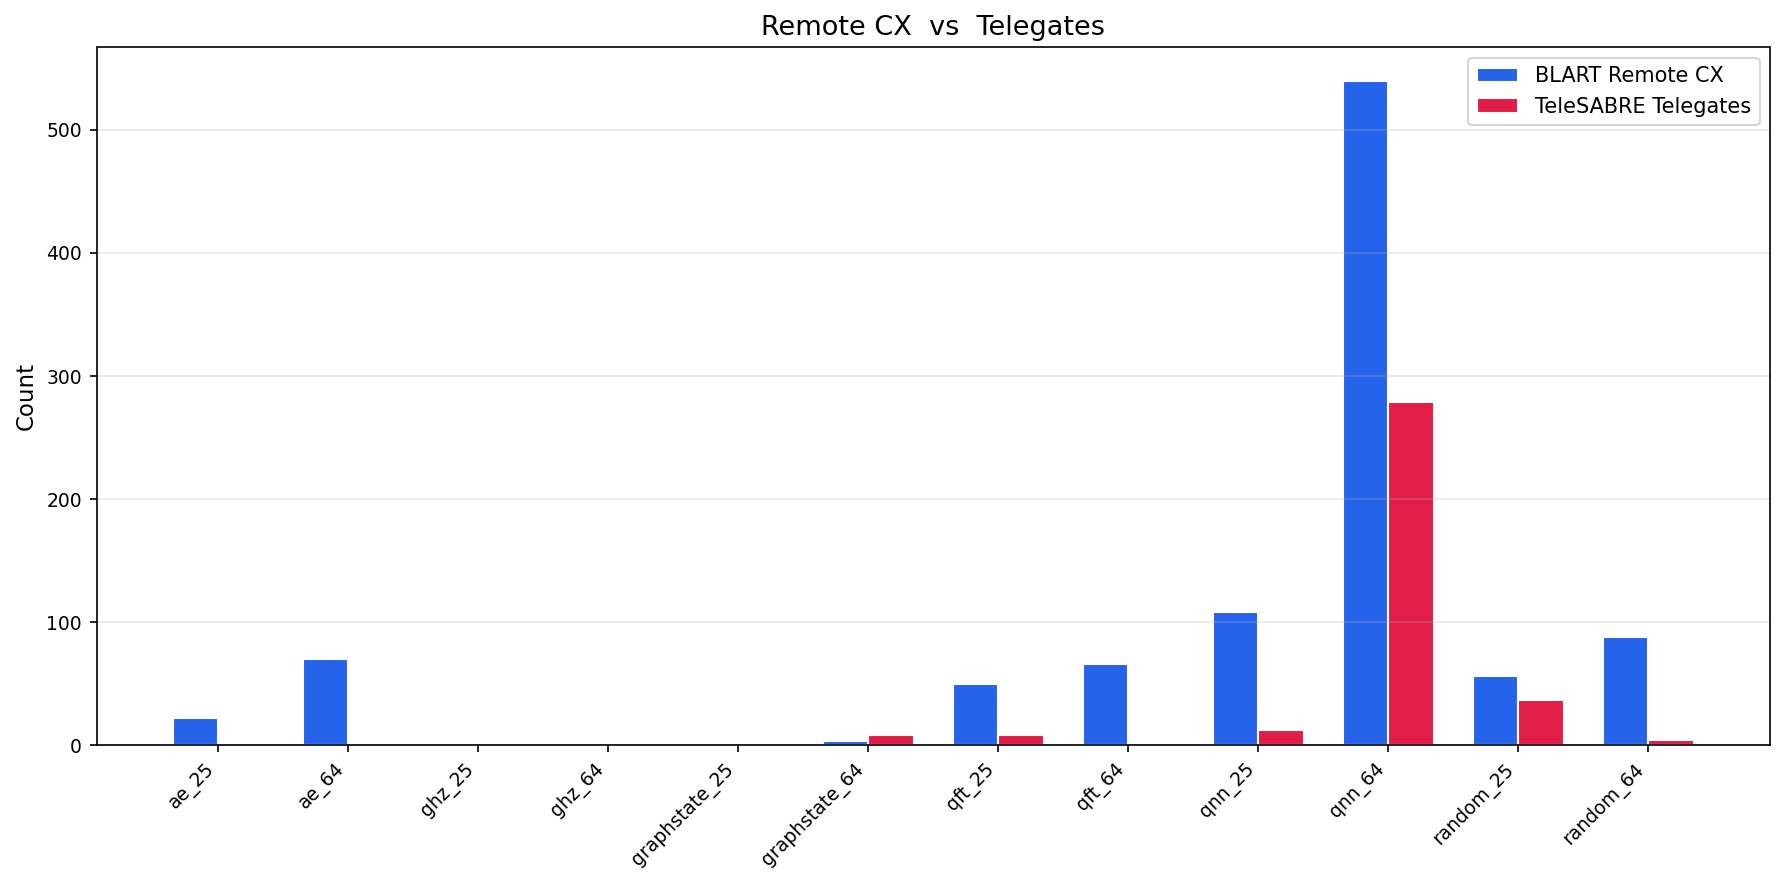

In [ ]:
bar_compare(b_cx_remote, t_telegates,
            "Count", "Remote CX  vs  Telegates",
            blart_label="BLART Remote CX", tele_label="TeleSABRE Telegates")